# Цель работы

Разработка и обучение модели для решения задачи бинарной классификации: на основании набора метрик, полученных от сонарных сигналов на 60 различных частотах, модель должна корректно определять тип подводного объекта — «мина» либо «камень».

Источник данных: https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('sonar.all-data.csv')

In [3]:
df.head()

,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9,Freq_10,...,Freq_52,Freq_53,Freq_54,Freq_55,Freq_56,Freq_57,Freq_58,Freq_59,Freq_60,Label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## Исследование данных

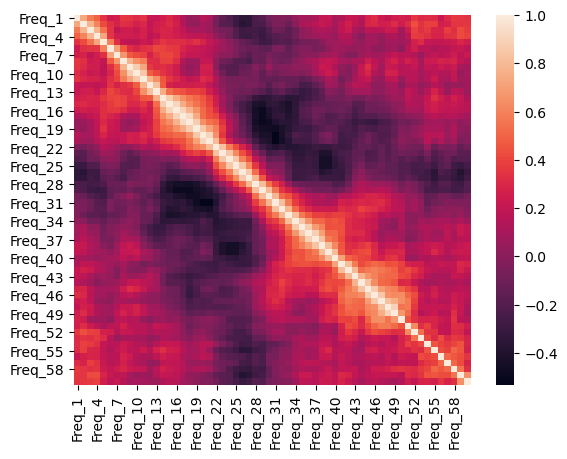

In [4]:
sns.heatmap(df.corr());

In [5]:
df['Target'] = df['Label'].map({'R':0,'M':1})

In [6]:
np.abs(df.corr()['Target']).sort_values(ascending=False).head(6)

Target     1.000000
Freq_11    0.432855
Freq_12    0.392245
Freq_49    0.351312
Freq_10    0.341142
Freq_45    0.339406
Name: Target, dtype: float64

## Обучение модели

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [8]:
X = df.drop(['Target','Label'],axis=1)
y = df['Target']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,random_state=245)

In [10]:
scaler = StandardScaler()

In [11]:
knn = KNeighborsClassifier(n_jobs=-1)

In [32]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [13]:
steps = [('scaler',scaler),('knn',knn)]

In [14]:
pipe = Pipeline(steps)

In [15]:
n_ne = list(range(1,30,2))

In [16]:
param_grid = {
    'knn__n_neighbors':n_ne
}

In [17]:
cv_classifier = GridSearchCV(pipe,param_grid,scoring='accuracy',cv=5,n_jobs=-1)

In [18]:
cv_classifier.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn',
                                        KNeighborsClassifier(n_jobs=-1))]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19,
                                              21, 23, 25, 27, 29]},
             scoring='accuracy')

In [20]:
cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_jobs=-1, n_neighbors=1))],
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_jobs=-1, n_neighbors=1),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': -1,
 'knn__n_neighbors': 1,
 'knn__p': 2,
 'knn__weights': 'uniform'}

## Оценка результатов

In [22]:
cv_classifier.cv_results_['mean_test_score']

array([0.85604552, 0.81849218, 0.79672831, 0.77012802, 0.73783784,
       0.73798009, 0.73826458, 0.71152205, 0.70611664, 0.7113798 ,
       0.72716927, 0.72716927, 0.71109531, 0.72702703, 0.72162162])

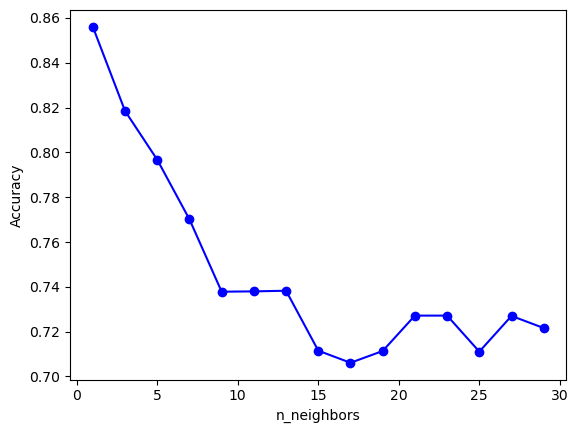

In [34]:
plt.plot(range(1,30,2),cv_classifier.cv_results_['mean_test_score'],'bo-')
plt.ylabel('Accuracy')
plt.xlabel('n_neighbors');

In [28]:
from sklearn.metrics import confusion_matrix, plot_confusion_matrix, classification_report

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       0.82      0.90      0.86        10

    accuracy                           0.86        21
   macro avg       0.86      0.86      0.86        21
weighted avg       0.86      0.86      0.86        21



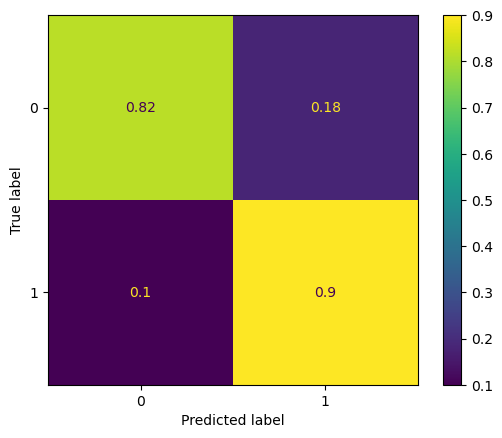

In [31]:
print(classification_report(y_test,cv_classifier.predict(X_test)))
plot_confusion_matrix(cv_classifier,X_test,y_test,normalize='true');